### INSTITUTO FEDERAL DE SÃO PAULO - Bragança Paulista SP
### Curso: Análise e Desenvolvimento de Sistemas
### Disciplina: Análise de Dados - BRAADAD
### Mini-Projeto 1
### Prof. César A. S. Lima, Dr.

## Data Munging - Manipulando Dados Para Previsão de AVC

## Problema de Negócio

O Acidente Vascular Cerebral (AVC) acontece quando vasos que levam sangue ao cérebro entopem ou se rompem, provocando a paralisia da área cerebral que ficou sem circulação sanguínea. É uma doença que acomete mais os homens e é uma das principais causas de morte, incapacitação e internações em todo o mundo.

Quanto mais rápido for o diagnóstico e o tratamento do AVC, maiores serão as chances de recuperação completa. Desta forma, torna-se primordial ficar atento aos sinais e sintomas e procurar atendimento médico imediato.

Existem dois tipos de AVC, que ocorrem por motivos diferentes: AVC hemorrágico e AVC isquêmico.

O que é um AVC isquêmico

O AVC isquêmico ocorre quando há obstrução de uma artéria, impedindo a passagem de oxigênio para células cerebrais, que acabam morrendo. Essa obstrução pode acontecer devido a um trombo (trombose) ou a um êmbolo (embolia). O AVC isquêmico é o mais comum e representa 85% de todos os casos.

O que é um AVC hemorrágico

O AVC hemorrágico ocorre quando há rompimento de um vaso cerebral, provocando hemorragia. Esta hemorragia pode acontecer dentro do tecido cerebral ou na superfície entre o cérebro e a meninge. É responsável por 15% de todos os casos de AVC, mas pode causar a morte com mais frequência do que o AVC isquêmico.

Quais os principais fatores de risco para desenvolver um AVC?

Existem diversos fatores que aumentam a probabilidade de ocorrência de um AVC, seja ele hemorrágico ou isquêmico. Os principais fatores causais das doenças são:

- Hipertensão;
- Diabetes tipo 2;
- Colesterol alto;
- Sobrepeso;
- Obesidade;
- Tabagismo;
- Uso excessivo de álcool;
- Idade avançada;
- Sedentarismo;
- Uso de drogas ilícitas;
- Histórico familiar;
- Ser do sexo masculino.

O AVC está altamente relacionado à idade, hipertensão, nível médio de glicose, status de tabagismo e IMC, enquanto isso depende parcialmente do sexo, doença cardíaca, tipo de trabalho e tipo de residência.

### Objetivo do Problema de Negócio

Para esse problema o valor da métrica deve ser superior a 97%, uma vez que a previsão do modelo está relacionada a casos de vida ou morte.

In [100]:
# Montagem do drive do Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Carregando os Dados

In [101]:
# Importando as bibliotecas pandas (excel), numpy (matemática) e matplotlib (gráficos)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Exibindo os gráficos nesta mesma página e não em outra aba. Comando do Jupyter Notebook.
%matplotlib inline

In [102]:
# Carregando os dados usando o pandas
dataset = pd.read_csv("/content/drive/MyDrive/IFSP/2026-2/BRAADAD/Aula2/dataset-data-munging-01.csv")

In [103]:
# Visualizando os primeiros 5 registros com o pandas
dataset.head()

,id,sexo,idade,hipertensao,doenca_coracao,casado,tipo_trabalho,tipo_residencia,media_nivel_glicose,imc,status_tabagismo,avc
0,30669,Masculino,3.0,0,0,No,crianca,Rural,95.12,18.0,NaN,0
1,30468,Masculino,58.0,1,0,Yes,Privado,Urbana,87.96,39.2,nunca fumou,0
2,16523,Feminino,8.0,0,0,No,Privado,Urbana,110.89,17.6,NaN,0
3,56543,Feminino,70.0,0,0,Yes,Privado,Rural,69.04,35.9,fuma eventualmente,0
4,46136,Masculino,14.0,0,0,No,Nunca_trabalhou,Rural,161.28,19.1,NaN,0


In [104]:
# Formato dos dados
# Quantidade de linhas e colunas do conjunto de dados do dataset (43400 linhas e 12 colunas)
dataset.shape

(43400, 12)

In [105]:
# Tipos dos dados das colunas do dataset utilizando pandas
dataset.dtypes

,0
id,int64
sexo,object
idade,float64
hipertensao,int64
doenca_coracao,int64
casado,object
tipo_trabalho,object
tipo_residencia,object
media_nivel_glicose,float64
imc,float64


In [106]:
# Verifica na coluna 'AVC' a quantidade de valores 0 (quem não teve AVC) e 1 (quem teve AVC)
dataset['avc'].value_counts()

,count
avc,
0,42617
1,783


### Identificando e Removendo Colunas Irrelevantes

O AVC está altamente relacionado à idade, hipertensão, nível médio de glicose, status de tabagismo e IMC, enquanto isso depende parcialmente do sexo, doença cardíaca, tipo de trabalho e tipo de residência.

A determinação da relevância de um dado é subjetivo. Quanto menos dados irrelevantes tivermos num conjunto de dados, maior será a taxa de eficácia do seu modelo. Mas, um analista pode considerar um tipo de dado relevante e para outro analista, não.

Neste caso, não há outra maneira do que cada analista criar seu modelo de acordo com suas convicções para depois comparar os resultados.

In [107]:
# Excluímos a coluna "id", não tem relevancia para previsão da variável
# alvo AVC.
del dataset['id']

In [108]:
# Excluímos a coluna "casado", já que não parece ser um bom identificador para prever um avc,
# algumas pessoas gostam de se casar, outras não, o que pode resultar em hipertensão ou
# vida estressada. Não há uma única pesquisa científica que afirme que ser casado ou não
# aumente o nível de estresse.
del dataset['casado']

In [109]:
# Coletando números estatísticos das colunas numéricas
dataset.describe()

,idade,hipertensao,doenca_coracao,media_nivel_glicose,imc,avc
count,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


In [110]:
# Extraindo variáveis do tipo categóricas ('object' é do tipo 'string')
# Esta linha retorna os índices das colunas cujo tipo de dados é igual a object (string).
# Observe que entre os colchetes, o pandas permite referenciar o tipo de coluna que se
# deseja filtrar.
dfcatname = dataset.dtypes[dataset.dtypes == 'object'].index

In [111]:
print(dfcatname)

Index(['sexo', 'tipo_trabalho', 'tipo_residencia', 'status_tabagismo'], dtype='object')


In [112]:
# Temos que separar as variáveis categóricas das variáveis do tipo numérica. Por exemplo:
# Variáveis como idade, nivel_medio_glicose e IMC são variáveis numéricas.
# Variáveis do tipo hipertensão (0 ou 1) e doença_coração (0 ou 1) são categóricas pois
# classificam o tipo de paciente como positivo (1) ou negativo (0).
# Extraindo variáveis do tipo numéricas contínuas e separando-as das variáveis categóricas.
# Este list comprehension retorna para uma lista cada item que percorre cada coluna do dataset
# se o item não estiver contido no DataFrame dfcatname (onde estão as variáveis categóricas).
# Observe que 'hipertensão' e 'doenca_coração' foram classificadas como númericas porque são
# 0 ou 1. Mas, são classificatórias, então, teremos que separá-las manualmente das
# variáveis categóricas, posteriormente.
dfconname = [item for item in dataset.columns if item not in list(dfcatname)]

In [113]:
print(dfconname)

['idade', 'hipertensao', 'doenca_coracao', 'media_nivel_glicose', 'imc', 'avc']


In [114]:
# Outra maneira de extrair os dados
# .index é o comando que "extrai" apenas os nomes das colunas
# que passaram no seu filtro.
dfnumname = dataset.dtypes[dataset.dtypes != 'object'].index

In [115]:
print(dfnumname)

Index(['idade', 'hipertensao', 'doenca_coracao', 'media_nivel_glicose', 'imc',
       'avc'],
      dtype='object')


#### Descrevendo as variáveis categóricas

In [116]:
# Observe que top é o valor mais frequente no DataFrame dfcatname
# (nome das variáveis categóricas)
# freq é a frequencia existente do valor da coluna top.
# Observe que a quantidade de registros da coluna status_tabagismo é diferente de sexo,
# tipo_trabalho ou tipo_residencia porque há status do tipo NaN (sem registro)
# O sexo com unique 3, significa que há 3 registros como masculino, feminino e
# sem identificação.
dataset[dfcatname].describe()

,sexo,tipo_trabalho,tipo_residencia,status_tabagismo
count,43400,43400,43400,30108
unique,3,5,2,3
top,Feminino,Privado,Urbana,nunca fumou
freq,25665,24834,21756,16053


### Tratamento de Valores Ausentes (Missing) no IMC

In [117]:
# O próximo passo é realizar o tratamento de dados ausentes. Serão dividido em duas partes:
# O tratamento de dados ausentes de variáveis qualitativas (categóricas) e de dados ausentes
# de variáveis quantitativas (numéricas) porque são abordagens é diferentes para tais variáveis.
# Coletando estatísticas das colunas.
# Observe que a coluna IMC contem um número de registros menor que as outras colunas.
# Isso quer dizer que este dado não foi calculado em alguns registros. Temos dados missing em IMC.
# Temos que tratar esta condição de alguma maneira.
dataset.describe()

,idade,hipertensao,doenca_coracao,media_nivel_glicose,imc,avc
count,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


In [118]:
# Descrevendo a coluna IMC
# A variável IMC é uma variável numérica. É possível fazer algumas abordagens.
# Criando a descrição estatística apenas para a coluna 'imc'
# Observe o valor da média, ou seja, 28.605038
dataset['imc'].describe()

,imc
count,41938.000000
mean,28.605038
std,7.770020
min,10.100000
25%,23.200000
50%,27.700000
75%,32.900000
max,97.600000


In [119]:
# Checando por valores missing
# Usando o pandas para descobrir a somatória de valores nulos, ou seja, que não foram preenchidos
# na coluna 'imc'. Observe que 1462 registros estão com valores nulos ou ausentes.
dataset['imc'].isna().sum()

np.int64(1462)

Uma maneira de tratar um valor ausente é simplesmente remover o registro completo, e em nosso exemplo teríamos que remover 1462/43400 o que é um número relativamente pequeno (3,3 %).

Outra solução quando trabalhamos com variáveis numéricas é imputar zero, valores centrais ou estatisticamente estimados, no lugar de NAN.

Para verificar se podemos atribuir valor central, vamos plotar o histograma.

<function matplotlib.pyplot.show(close=None, block=None)>

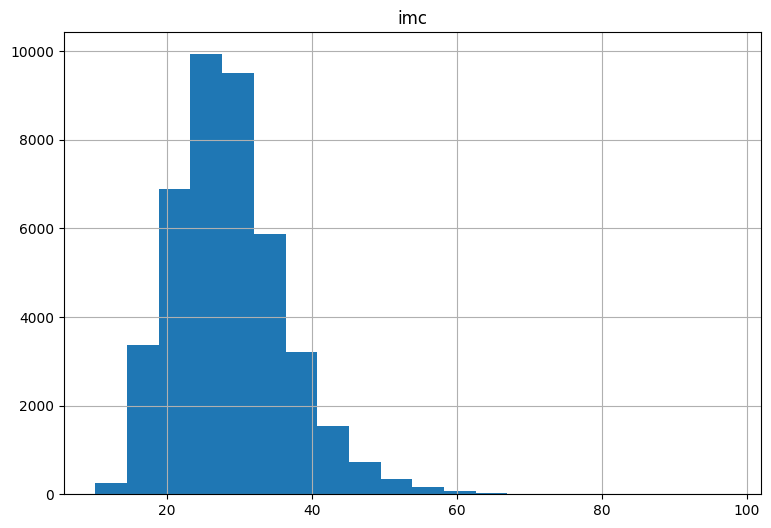

In [120]:
# Neste exemplo, escolheremos atribuir o valor da média se os dados forem uma distribuição normal.
# Se fosse poucos números de registros, então, poderiamos excluí-los, mas, 1462 registros é
# número alto
# Imputar valor zero a imc não uma boa solução porque imc = 0, significa ser um esqueleto.
# Outra alternativa é imputar um valor central a estes dados caso os valores sejam de
# distribuição normal. Para verificar estes dados cabe criar um historama.
# O histograma irá mostrar se os dados são uma distribuição normal (formato de sino invertido),
# ou seja, distribuição normal de frequencia.
# Será criado um histograma da coluna 'imc', onde figsize é o tamanho da figura e bins é a
# quantidade de colunas de dados que serão colocadas no histograma, neste caso, 20 colunas.
dataset.hist(column = 'imc', figsize=(9, 6), bins=20)
plt.show

Vê-se no histograma que os dados seguem uma distribuição normal. O valor do IMC entre 20 e 40 é o mais comum, portanto, não é totalmente irracional utilizá-lo no lugar de valores missing. No caso da distribuição normal a média, mediana e moda são iguais.

Vamos imputar a tendência central (média) no lugar de valores ausentes.

In [121]:
# Gera o novo imc
# Onde 'imc' for nulo, preenche com a média, senão, mantemos o valor atual.
# O método where do numpy faz o seguinte teste:
# se o dado da coluna 'imc' for nulo, preenche este dado
# com a média de imc. Se o dado não for nulo, mantém o seu valor original.
# Não podemos submeter dados ausentes aos algoritmos de machine learning porque
# eles não interpretam dados ausentes.
# A sintaxe básica dele é:
# np.where(condição, valor_se_verdadeiro, valor_se_falso)
novo_imc = np.where(dataset['imc'].isnull(), dataset['imc'].mean(), dataset['imc'])

In [122]:
# exibe o novo_imc
print(novo_imc)

[18.  39.2 17.6 ... 28.9 33.2 20.6]


In [123]:
# Grava o novo valor do imc no dataset
# Substituindo os valores da coluna 'imc' pelos novos valores de imc calculados.
dataset['imc'] = novo_imc

In [124]:
# Na descrição de dados estatísticos, observa-se que não houve alteração dos dados.
# A média continua com o mesmo valor anterior, ou seja, 28.605038
dataset['imc'].describe()

,imc
count,43400.000000
mean,28.605038
std,7.638023
min,10.100000
25%,23.400000
50%,28.100000
75%,32.600000
max,97.600000


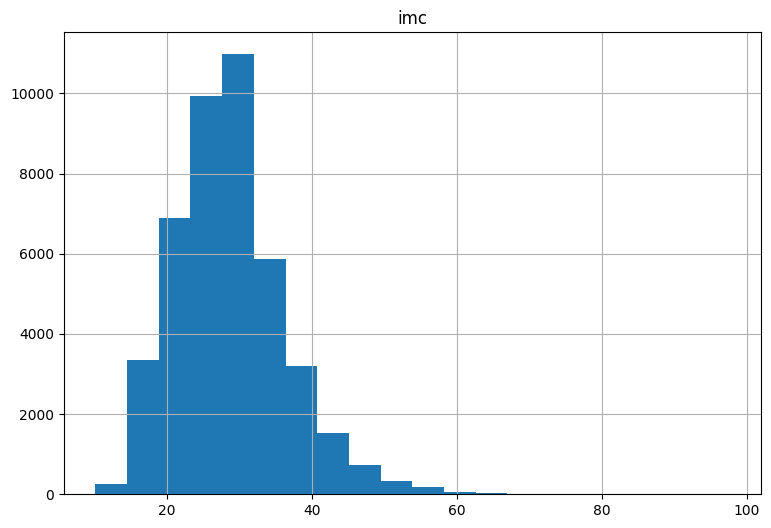

In [125]:
# Checando o histograma
dataset.hist(column = 'imc', figsize=(9,6), bins=20)
plt.show()

### Tratamento de Valores Missing no Status de Tabagismo

In [126]:
# Mas, como tratar um dado se uma variável é do tipo categórica (classificação)?
# Descrevendo as variáveis categóricas
# Observe que status_tabagismo possui 30108 registros preenchidos, assim,
# mais de 13292 (30,6%) estão ausentes, de um total de 43400.
# O número alto de dados ausentes inviabiliza a exclusão destes registros.
dataset[dfcatname].describe()

,sexo,tipo_trabalho,tipo_residencia,status_tabagismo
count,43400,43400,43400,30108
unique,3,5,2,3
top,Feminino,Privado,Urbana,nunca fumou
freq,25665,24834,21756,16053


In [127]:
# Observe na descrição a seguir que unique=3 significa que existem 3 categorias de dados:
# Nunca fumou, fuma eventualmente e fuma.
dataset['status_tabagismo'].describe()

,status_tabagismo
count,30108
unique,3
top,nunca fumou
freq,16053


In [128]:
# Somatória de valores nulos ou ausentes para a coluna 'status_tabagismo.
dataset['status_tabagismo'].isnull().sum()

np.int64(13292)

In [129]:
# Verificando a quantidade de registros por tipo em 'status_tabagismo'
dataset['status_tabagismo'].value_counts()

,count
status_tabagismo,
nunca fumou,16053
fuma eventualmente,7493
fuma,6562


<Axes: xlabel='status_tabagismo'>

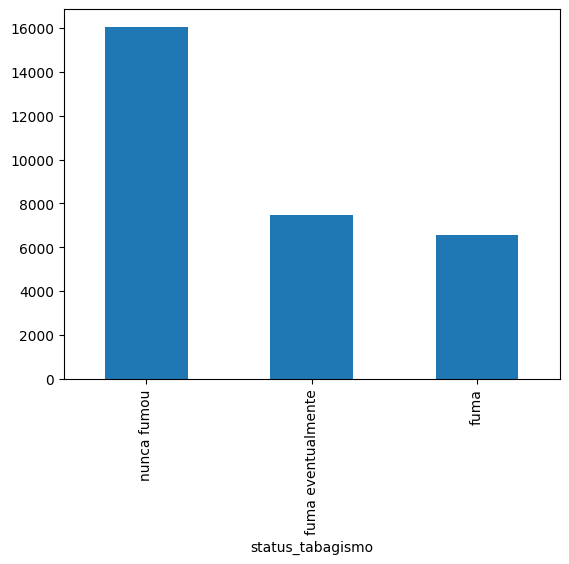

In [130]:
# Gráfico de barras para a quantidade de valores para cada um das 3 categorias
# da coluna status de tabagismo.
dataset['status_tabagismo'].value_counts().plot(kind='bar')

Não há como fazer uma média aritmética entre as três categorias simultaneamente. Vamos preencher os valores missing com uma nova categoria chamada "desconhecido".

In [131]:
# Usando o método where do numpy para criar uma nova categoria chamada 'desconhecido' caso
# o dado seja ausente. Se não for, mantenha-se os dados originais.
novo_status_tabagismo = np.where(dataset['status_tabagismo'].isnull(), 'desconhecido', dataset['status_tabagismo'])

In [132]:
# Acrescentando à coluna 'status_tabagismo' o novo status 'desconhecido' em substituição a nulo.
dataset['status_tabagismo'] = novo_status_tabagismo

<function matplotlib.pyplot.show(close=None, block=None)>

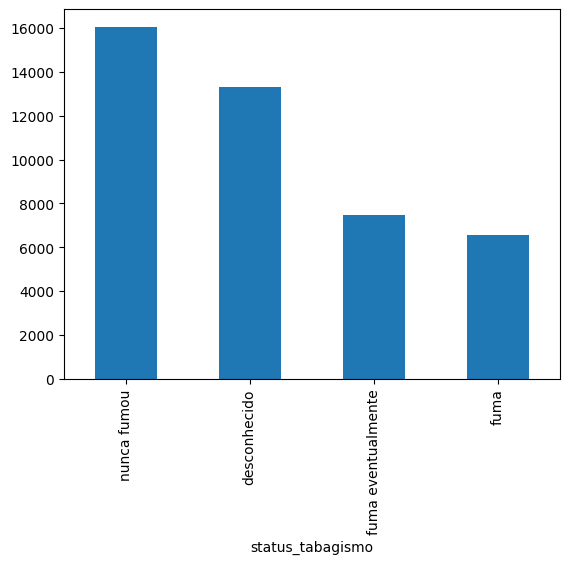

In [133]:
# Construindo um novo grátfico para mostrar a nova categoria do status_tabagismo.
dataset['status_tabagismo'].value_counts().plot(kind='bar')
plt.show

In [134]:
# Mostrando a quantidade de registros para cada coluna.
# Todas as colunas, agora, tem o mesmo valor.
dataset.count()

,0
sexo,43400
idade,43400
hipertensao,43400
doenca_coracao,43400
tipo_trabalho,43400
tipo_residencia,43400
media_nivel_glicose,43400
imc,43400
status_tabagismo,43400
avc,43400


### Tratamento de Outliers

In [135]:
# Tratamento de Outliers ou de valores extremos para cada variável.
# valores extremos são valores considerados como ponto fora da curva.
# São dados que poderão ser inseridos de forma errônea por algum motivo.
# Ou, em alguns casos, como procura de valores fraudulentos ou superfaturados,
# o valor extremo é justamente aquele que deverá ser estudado.
# A maioria dos valores são do tipo não fraudulento. O extremo, poderá ser
# o valor a ser estudado porque ele pode ser a fraude que se está procurando.
# dfconname é o DataFrame com as variáveis numéricas contínuas.
# O valor extremo estará sempre em variáveis quantitativas (0 ou 1) e nunca em categóricas.
# Hipertensão, doenca_coracao e avc são variáveis categóricas, 0 e 1.
# Não temos valores outliers nelas.
dataset[dfconname]

,idade,hipertensao,doenca_coracao,media_nivel_glicose,imc,avc
0,3.0,0,0,95.12,18.0,0
1,58.0,1,0,87.96,39.2,0
2,8.0,0,0,110.89,17.6,0
3,70.0,0,0,69.04,35.9,0
4,14.0,0,0,161.28,19.1,0
...,...,...,...,...,...,...
43395,10.0,0,0,58.64,20.4,0
43396,56.0,0,0,213.61,55.4,0
43397,82.0,1,0,91.94,28.9,0
43398,40.0,0,0,99.16,33.2,0


In [136]:
# Verificando a existência de valores outliers nas colunas idade [0], media_nivel_glicose[3]
# e imc[4]
# Verificando outliers na coluna idade, indice [0], através da descrição de valores estatísticos.
# O método describe() do pandas, informa os valores estatísticos
# Checar os valores da média (mean), minimo (min) e máximo (max).
# Neste caso, temos crianças com 8 dias de vida a pessoas de 82 anos de idade, o que é razoável.
# Não há valores extremos neste caso.
dataset[dfconname[0]].describe()

,idade
count,43400.000000
mean,42.217894
std,22.519649
min,0.080000
25%,24.000000
50%,44.000000
75%,60.000000
max,82.000000


In [137]:
# Verificando a existência de valores outliers na coluna media_nivel_glicose[3]
# O valor máximo de 291.05 parece ser muito extremo, a não ser que o paciente
# esteja com a diabetes descontrolada.
dataset[dfconname[3]].describe()

,media_nivel_glicose
count,43400.000000
mean,104.482750
std,43.111751
min,55.000000
25%,77.540000
50%,91.580000
75%,112.070000
max,291.050000


In [138]:
# Verificando a existência de valores outliers na coluna imc[4]
# O valor maximo de 97.6 está extremamente alto.
# Uma pessoa com imc com obesidade mórbida é de 50.
dataset[dfconname[4]].describe()

,imc
count,43400.000000
mean,28.605038
std,7.638023
min,10.100000
25%,23.400000
50%,28.100000
75%,32.600000
max,97.600000


<Axes: >

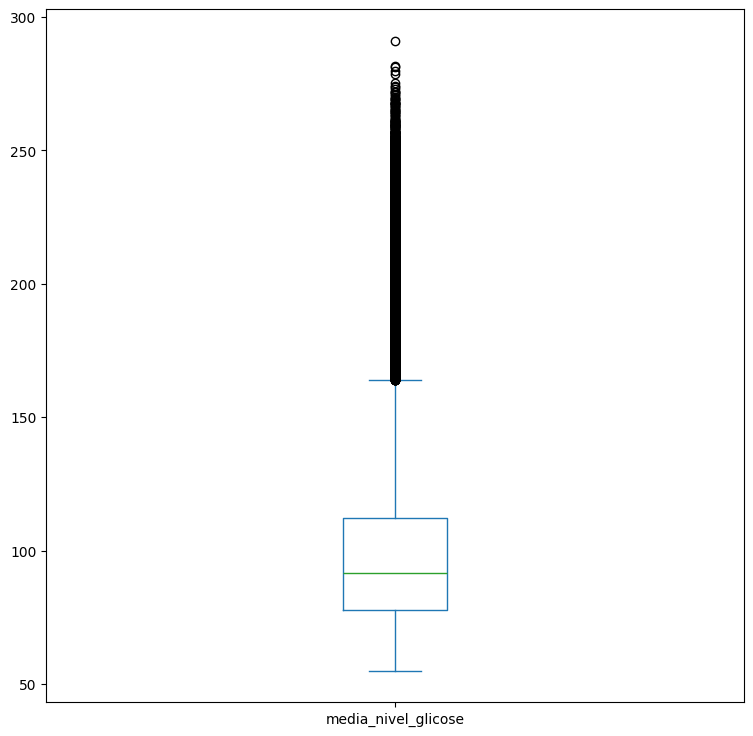

In [139]:
# Verificando outliers para recursos numéricos em nosso conjunto de dados.
# Variável media_nivel_glicose, coluna indice [3]
# Este gráfico do tipo caixa, mostra o valor mínimo 55, e o valor máximo de 291.05 está fora
# dos limites do gráfico, ou seja, ponto 0. Este é um valor outlier (extremo)
# Neste caso, é um único valor, então este registro será removido.
dataset[dfconname[3]].plot(kind="box", figsize=(9,9 ))

In [140]:
# Removendo outliers
# Exibindo o valor outlier que será removido.
# O método where do numpy, procura o valor max na coluna "media_nivel_glicose"
# do dataset "media_nivel_glicose".
index1=np.where(dataset["media_nivel_glicose"] == max(dataset["media_nivel_glicose"]))
print(type(index1))
print(index1)

<class 'tuple'>
(array([38446]),)


In [141]:
# Localiza e mostra o registro contido na variável index1, o valor maximo de "media_nivel_glicose"
dataset.loc[index1]

,sexo,idade,hipertensao,doenca_coracao,tipo_trabalho,tipo_residencia,media_nivel_glicose,imc,status_tabagismo,avc
38446,Feminino,80.0,0,0,Privado,Rural,291.05,28.7,nunca fumou,0


In [142]:
# Removendo o registro com o "media_nivel_glicose" de 291,05
# O método drop referencia o registro que está dentro do objeto index1 (tupla) em sua posição [0].
dataset = dataset.drop(index1[0])

<Axes: >

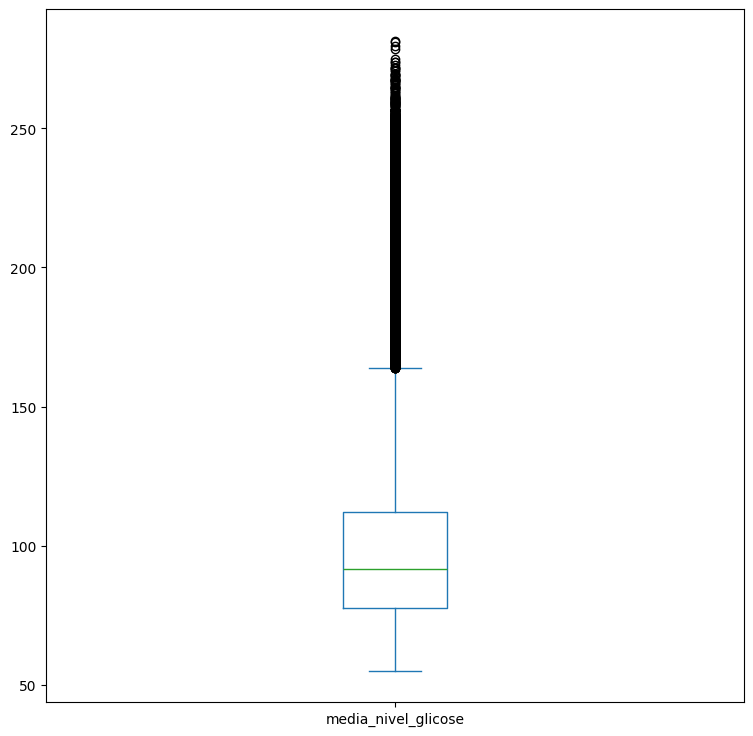

In [143]:
# Verificando outliers para recursos numéricos em nosso conjunto de dados
# coluna "media_nivel_glicose" indice [3]. Observe que o ponto 0 foi removido.
dataset[dfconname[3]].plot(kind="box", figsize=(9,9))

In [144]:
# Totalizando a quantidade de registros da coluna media_nivel_glicose acima de 200.
total = (dataset["media_nivel_glicose"] > 200).sum()
print(f"Total de Registros > 200: {total}")

Total de Registros > 200: 3167


In [145]:
# Análise descritiva estatística da coluna 'imc'
dataset[dfconname[4]].describe()

,imc
count,43399.000000
mean,28.605036
std,7.638111
min,10.100000
25%,23.400000
50%,28.100000
75%,32.600000
max,97.600000


<Axes: >

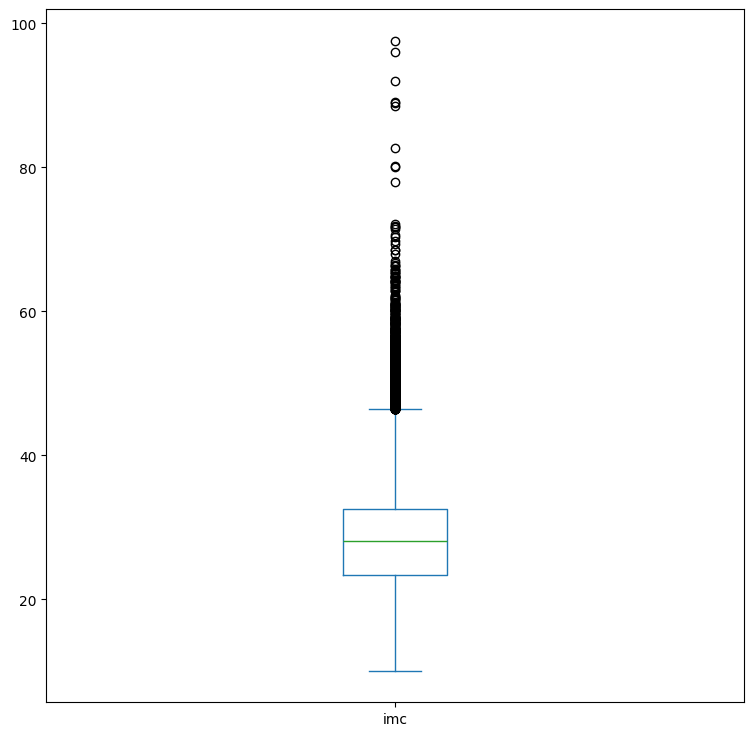

In [146]:
# Verificando outliers para recursos numéricos em nosso conjunto de dados.
# Variável imc
dataset[dfconname[4]].plot(kind="box", figsize=(9,9))

In [147]:
# Exibindo o valor outlier que será removido.
# O método where do numpy, procura o valor max na coluna "imc"
# do dataset.
index2 = np.where(dataset['imc'] == max(dataset['imc']))

In [148]:
# Localiza e mostra o registro contido na variável index2, o valor maximo de "imc"
dataset.loc[index2]

,sexo,idade,hipertensao,doenca_coracao,tipo_trabalho,tipo_residencia,media_nivel_glicose,imc,status_tabagismo,avc
1913,Masculino,17.0,1,0,Privado,Rural,61.67,97.6,desconhecido,0


O valor do IMC pode chegar ao máximo de até 54, o que também é um caso muito raro, mas nosso conjunto de dados tem alguns valores maiores que 54, que também atuam apenas como outliers, eu prefiro removê-los mantendo a margem. Isso não afetará os dados, e os manterão realistas.

In [149]:
# Filtrando os registros cujo imc são menores que 60 (para dar uma folga) e armazenando de
# volta ao dataset.
# Serão removidos os registros cujos imc's são superiores a 60.
dataset = dataset[dataset['imc'] < 60.]

In [150]:
# Observe que o número de registros baixou de 43400 para 43309 em todas as colunas uniformemente.
# Assim, todos com imc acima de 60 foram removidos
dataset.count()

,0
sexo,43309
idade,43309
hipertensao,43309
doenca_coracao,43309
tipo_trabalho,43309
tipo_residencia,43309
media_nivel_glicose,43309
imc,43309
status_tabagismo,43309
avc,43309


In [151]:
# Exibindo os primeiros registros do dataset.
# Atenção: Algoritmos de Machine Learning não aceitam variáveis de tipo string.
# Assim, será necessário transformar variáveis como sexo, tipo_trabalho, tipo_residencia
# e status_tabagismo para variáveis categóricas numéricas.
dataset.head()

,sexo,idade,hipertensao,doenca_coracao,tipo_trabalho,tipo_residencia,media_nivel_glicose,imc,status_tabagismo,avc
0,Masculino,3.0,0,0,crianca,Rural,95.12,18.0,desconhecido,0
1,Masculino,58.0,1,0,Privado,Urbana,87.96,39.2,nunca fumou,0
2,Feminino,8.0,0,0,Privado,Urbana,110.89,17.6,desconhecido,0
3,Feminino,70.0,0,0,Privado,Rural,69.04,35.9,fuma eventualmente,0
4,Masculino,14.0,0,0,Nunca_trabalhou,Rural,161.28,19.1,desconhecido,0


### Convertendo Variáveis Categóricas em Valores Numéricos

Os algoritmos de Machine Learning não trabalham com variáveis do tipo string porque realizam cálculos matemáticos entre variáveis numéricas. Então, variáveis como sexo, tipo_trabalho e status_tabagismo deverão ser convertidas em variáveis numéricas.

In [152]:
# Listando as variáveis categóricas
# O DataFrame dfcatname contem o nome e o conteúdo das variáveis categóricas.
# O método head() mostra os primeiros registros.
dataset[dfcatname].head()

,sexo,tipo_trabalho,tipo_residencia,status_tabagismo
0,Masculino,crianca,Rural,desconhecido
1,Masculino,Privado,Urbana,nunca fumou
2,Feminino,Privado,Urbana,desconhecido
3,Feminino,Privado,Rural,fuma eventualmente
4,Masculino,Nunca_trabalhou,Rural,desconhecido


### Tipos de Abordagem

Existem dois tipos de abordagem para conversão de variáveis categóricas para variáveis numéricas.
Usa-se Label Encoding nas colunas com 3 ou menos categorias. Sexo e tipo_residencia serão tratados com a técnicas de Label Encoding. Já tipo_trabalho e status_tabagismo, será utilizada outra técnica, o One-Hot Encoding porque possuem mais de 3 categorias.

### Diferenças entre variáveis String e variáveis Categóricas

<b>Variável string</b><br>
Uma variável string (ou de texto) é uma sequência de caracteres. Ela é usada para armazenar dados não estruturados, como nomes, endereços, descrições ou qualquer outro tipo de texto livre.

Imagine que você está trabalhando com um conjunto de dados de clientes e tem uma coluna chamada "Feedback". Nela, cada cliente escreveu um comentário sobre sua experiência com um produto. O conteúdo de cada célula nessa coluna é uma string, pois pode ser qualquer texto que o cliente digitou.

Geralmente, variáveis strings não podem ser usadas diretamente em cálculos matemáticos ou na maioria dos modelos de machine learning. Elas precisam ser pré-processadas, o que pode incluir a tokenização (dividir o texto em palavras), a remoção de pontuação e o uso de técnicas como a criação de vetores (vectorization) para transformá-las em um formato numérico.

<b>Variável categórica</b><br>
Uma variável categórica (ou de fator) representa características que podem ser divididas em grupos ou categorias. Em geral, os valores são extraídos de um conjunto limitado de possibilidades.

Por exemplo, a variável "Status do Pedido" em um e-commerce pode ter valores como: "Em Processamento", "Enviado", "Entregue" ou "Cancelado". Mesmo que esses valores sejam palavras, eles representam categorias fixas e pré-definidas.

<b>As variáveis categóricas podem ser de dois tipos:</b>

<b>Nominais:</b> as categorias não têm uma ordem intrínseca. Por exemplo, a variável "Cor dos Olhos" pode ter valores como: "Azul", "Verde" ou "Castanho". Nenhuma cor é "maior" ou "melhor" que a outra.

<b>Ordinais:</b> as categorias têm uma ordem ou hierarquia clara. Um exemplo seria a variável "Nível de Satisfação" com valores como: "Muito Insatisfeito", "Insatisfeito", "Neutro", "Satisfeito" e "Muito Satisfeito". A ordem aqui é importante.

Para serem usadas em modelos de machine learning, as variáveis categóricas também precisam ser transformadas em um formato numérico. Técnicas comuns incluem a codificação de rótulo (<b>label encoding</b>) ou a codificação one-hot (<b>one-hot encoding</b>).

In [153]:
# Exibição da descrição de dados estatísticos do objeto dfcatname:
# A quantidade de registros (count), unique (valores únicos para uma coluna), top (valor mais
# frequente), freq (frequencia de valores top) de uma coluna.
# Categorias que possuem valores unicos menores ou iguais a 3 terão um tipo de abordagem, ou seja,
# o Label Encoding. Sexo possui 3 valores únicos e tipo_residência 2 valores únicos.
# Categorias maiores que 3 valores únicos terão outro tipo de abordagem.
# Assim, em sexo e tipo_residencia será aplicada uma técnica de conversão de dados para valores
# numéricos e acima de 3, será aplicada outra técnica, chamada de One Hot Encoding.
dataset[dfcatname].describe()

,sexo,tipo_trabalho,tipo_residencia,status_tabagismo
count,43309,43309,43309,43309
unique,3,5,2,4
top,Feminino,Privado,Urbana,nunca fumou
freq,25605,24770,21712,16016


In [154]:
# Os tres valores unicos para sexo são:
# 'Masculino', 'Feminino' e 'outro'
dataset['sexo'].unique()

array(['Masculino', 'Feminino', 'Outro'], dtype=object)

In [155]:
# Os dois valores unicos para tipo_residencia são:
# 'Rural' e 'Urbana'
dataset['tipo_residencia'].unique()

array(['Rural', 'Urbana'], dtype=object)

Usaremos Label Encoding nas colunas tendo 3 ou menos categorias.

In [156]:
# Serão convertidos os valores únicos de sexo para variaveis numericas.
# O Label Encoding é a técnica responsável para realizar essas conversões.
# A coluna 'sexo' do dataset está sendo convertida de string para categórica e armazena-se de volta
# ao objeto dataset para coluna 'sexo'.
# Isto é feito para que o atributo cat.codes possa determinar os códigos numéricos
# a cada variável do sexo como masculino, feminino e outros.
dataset['sexo'] = dataset['sexo'].astype('category')

In [157]:
# Serão convertidos os valores únicos de tipo_residencia para variaveis numericas.
# A coluna 'tipo_residencia' do dataset está sendo convertida de string para categórica
# e armazena-se de volta ao objeto dataset para coluna 'tipo_residencia'.
# Isto é feito para que o atributo cat.codes possa determinar os códigos numéricos
# a cada variável do tipo_residencia como urbana e rural.
dataset.dtypes

,0
sexo,category
idade,float64
hipertensao,int64
doenca_coracao,int64
tipo_trabalho,object
tipo_residencia,object
media_nivel_glicose,float64
imc,float64
status_tabagismo,object
avc,int64


In [158]:
# O atributo cat.codes atribuirá códigos numéricos para a categoria 'sexo'.
# Masculino será convertido para 1, Feminino para 0 e Outro para 2.
dataset['sexo'] = dataset['sexo'].cat.codes

In [159]:
# A mesma técnica é feita para coluna 'tipo_residencia'.
# 'Rural' receberá o valor 0 e 'Urbana' o valor 1.
dataset['tipo_residencia'] = dataset['tipo_residencia'].astype('category')
dataset['tipo_residencia'] = dataset['tipo_residencia'].cat.codes

In [160]:
# Exibindo os primeiros registros. Observe que 'sexo' e 'tipo_residencia' receberam valores numéricos.
# Não se pode trabalhar com a técnica label Encoding para colunas que possuem mais do que 3 valores
# únicos, porque, o algoritmo de Machine Learning irá tratar esses valores numéricos como
# sequenciais e poderão realizar seu aprendizado de forma errada.
dataset.head()

,sexo,idade,hipertensao,doenca_coracao,tipo_trabalho,tipo_residencia,media_nivel_glicose,imc,status_tabagismo,avc
0,1,3.0,0,0,crianca,0,95.12,18.0,desconhecido,0
1,1,58.0,1,0,Privado,1,87.96,39.2,nunca fumou,0
2,0,8.0,0,0,Privado,1,110.89,17.6,desconhecido,0
3,0,70.0,0,0,Privado,0,69.04,35.9,fuma eventualmente,0
4,1,14.0,0,0,Nunca_trabalhou,0,161.28,19.1,desconhecido,0


Usaremos One-Hot Encoding nas colunas com mais de 3 categorias. Essa técnica aumenta o número de colunas no conjunto de dados.

In [161]:
import os
# Mostrando a rota de diretórios dos arquivos de imagens
print(os.getcwd())

/content


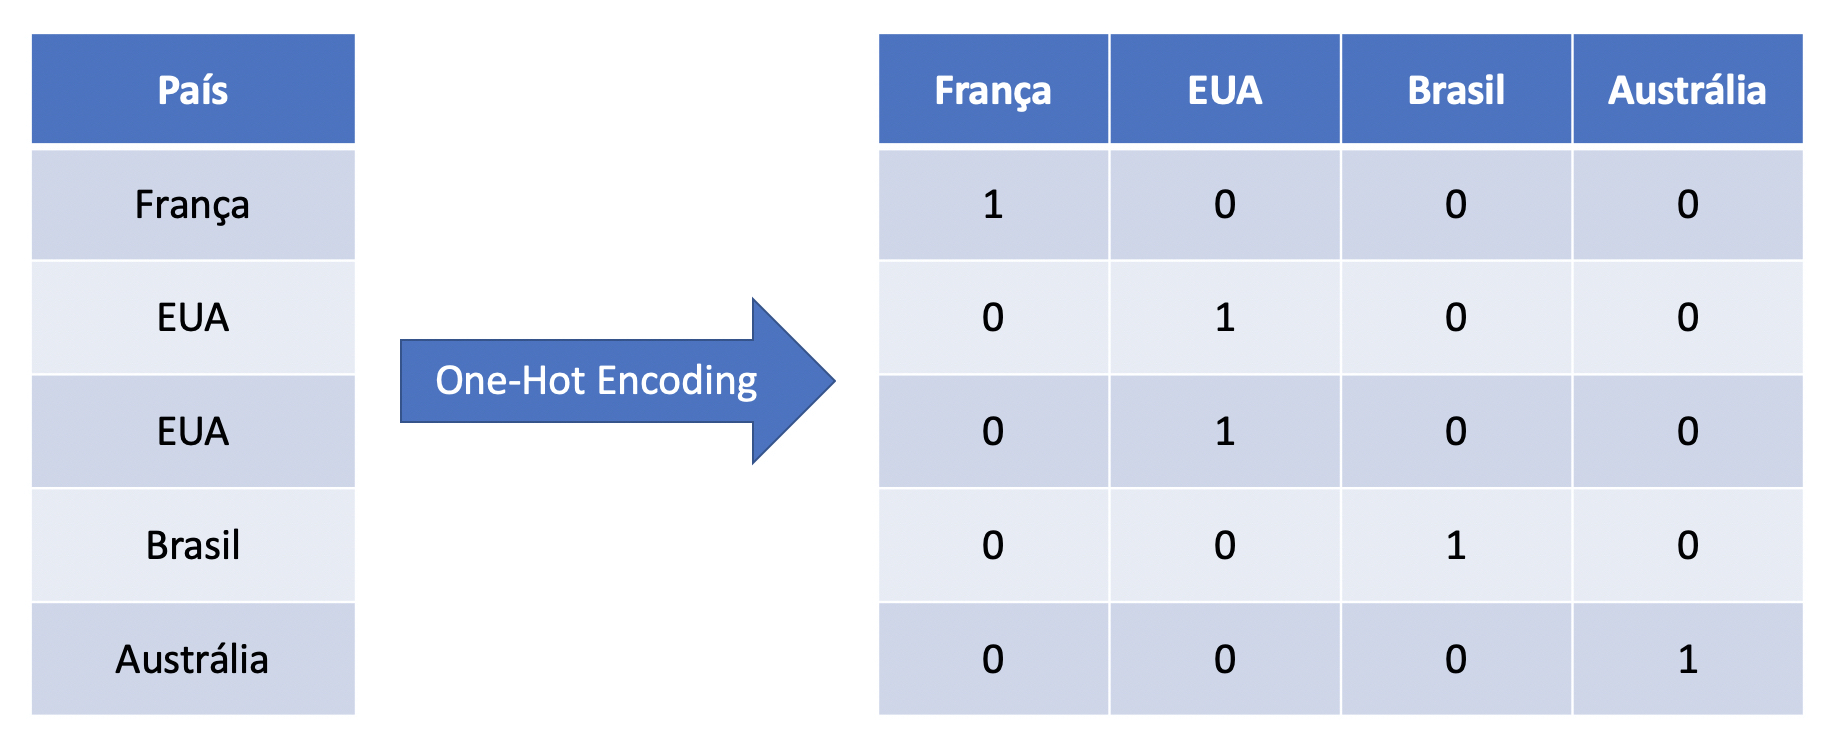

In [162]:
from IPython.display import display, Image
display(Image('/content/drive/MyDrive/IFSP/2026-2/BRAADAD/Aula2/one-hot-encoding.png'))
# No exemplo da figura a seguir, temos um vetor de 4 categorias, ou seja, 4 países.
# O One-Hot Encoding é uma matriz cujas colunas possuem as categorias.
# O conteúdo da matriz irá mostrar o valor convertido em um número na posição em que a categoria
# aparece. Assim, no vetor País, França aparece na primeira posição. Na matriz One-Hot Encoding,
# na coluna França, onde há a coincidência com o nome do país, recebe-se o número 1 e os demais
# Paízes desta coluna recebem 0.
# Assim, EUA recebem valores de número 1 na segunda e terceira posições e 0 nas demais.
# Brasil recebe 1 na quarta posição e 0 nas demais.
# Austrália recebe 1 na última posição e 0 nas demais

In [163]:
# O One-Hot Encoding aumenta o número de colunas.
# No método get_dummies do pandas, temos que informar as colunas do dataset cujos dados
# serão convertidos para números, neste caso, 'tipo_trabalho','status_tabagismo'.
# A coluna tipo_trabalho será substituída por 4 colunas. Cada uma delas terá o prefixo
# trabalho acompanhado de cada um dos seus valores do tipo string. Assim, serão criadas as colunas
# trabalho_Autonomo, trabalho_Nunca_trabalhou, trabalho_Privado e trabalho_Servidor_Publico.
# Se na coluna 'trabalho_Autonomo' um registro recebeu o valor 0, significa que este trabalhador
# não é trabalhador autônomo. Se receber o valor 1, significa que ele é trabalhador autônomo.
# Tal regra é repetida para cada nova coluna de trabalhador criada.
# O mesmo processo acontece com a coluna de prefixo tabagismo e seus 4 valores únicos. Cada valor
# recebe uma coluna com os valores 0 ou 1.
dataset = pd.get_dummies(dataset, columns=['tipo_trabalho', 'status_tabagismo'], prefix=['trabalho', 'tabagismo'])
dataset = dataset.astype(int)

In [164]:
dataset.head()

,sexo,idade,hipertensao,doenca_coracao,tipo_residencia,media_nivel_glicose,imc,avc,trabalho_Autonomo,trabalho_Nunca_trabalhou,trabalho_Privado,trabalho_Servidor_Publico,trabalho_crianca,tabagismo_desconhecido,tabagismo_fuma,tabagismo_fuma eventualmente,tabagismo_nunca fumou
0,1,3,0,0,0,95,18,0,0,0,0,0,1,1,0,0,0
1,1,58,1,0,1,87,39,0,0,0,1,0,0,0,0,0,1
2,0,8,0,0,1,110,17,0,0,0,1,0,0,1,0,0,0
3,0,70,0,0,0,69,35,0,0,0,1,0,0,0,0,1,0
4,1,14,0,0,0,161,19,0,0,1,0,0,0,1,0,0,0


### Machine Learning - Classificação

In [165]:
# Exibindo a descrição estatística do dataset atual com um maior número de colunas,
# devido a aplicação da regra One-Hot Encoding. Temos apenas variáveis númericas.
dataset.describe()

,sexo,idade,hipertensao,doenca_coracao,tipo_residencia,media_nivel_glicose,imc,avc,trabalho_Autonomo,trabalho_Nunca_trabalhou,trabalho_Privado,trabalho_Servidor_Publico,trabalho_crianca,tabagismo_desconhecido,tabagismo_fuma,tabagismo_fuma eventualmente,tabagismo_nunca fumou
count,43309.000000,43309.000000,43309.00000,43309.000000,43309.000000,43309.000000,43309.000000,43309.000000,43309.000000,43309.000000,43309.000000,43309.000000,43309.000000,43309.000000,43309.000000,43309.000000,43309.000000
mean,0.409037,42.200259,0.09326,0.047542,0.501328,103.949595,28.071486,0.018079,0.156480,0.004087,0.571937,0.125378,0.142118,0.306380,0.151123,0.172689,0.369808
std,0.492178,22.557213,0.29080,0.212798,0.500004,43.057941,7.437239,0.133240,0.363314,0.063799,0.494804,0.331151,0.349175,0.460995,0.358173,0.377983,0.482758
min,0.000000,0.000000,0.00000,0.000000,0.000000,55.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,24.000000,0.00000,0.000000,0.000000,77.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,44.000000,0.00000,0.000000,1.000000,91.000000,28.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,60.000000,0.00000,0.000000,1.000000,112.000000,32.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
max,2.000000,82.000000,1.00000,1.000000,1.000000,281.000000,59.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [166]:
# Divisão dos dados em X (entrada de dados) e Y (saída de dados)
# Para variável X, o metodo loc localiza todas as linhas
# (por isso o 'dois pontos': antes da virgula ','), cujas colunas do dataset são diferentes de 'avc'.
# Assim, todas as colunas com exceção de 'avc' estarão armazenadas em X.
X = dataset.loc[:, dataset.columns != 'avc']
# Em Y, será armazenada os dados do dataset referentes à coluna 'avc'.
Y = dataset['avc']

In [167]:
# Parâmetros para a divisão dos dados em treino e teste
# seed é parâmetro de treino e test_size é parâmetro de treino.
X.head()

,sexo,idade,hipertensao,doenca_coracao,tipo_residencia,media_nivel_glicose,imc,trabalho_Autonomo,trabalho_Nunca_trabalhou,trabalho_Privado,trabalho_Servidor_Publico,trabalho_crianca,tabagismo_desconhecido,tabagismo_fuma,tabagismo_fuma eventualmente,tabagismo_nunca fumou
0,1,3,0,0,0,95,18,0,0,0,0,1,1,0,0,0
1,1,58,1,0,1,87,39,0,0,1,0,0,0,0,0,1
2,0,8,0,0,1,110,17,0,0,1,0,0,1,0,0,0
3,0,70,0,0,0,69,35,0,0,1,0,0,0,0,1,0
4,1,14,0,0,0,161,19,0,1,0,0,0,1,0,0,0


In [168]:
Y.head()

,avc
0,0
1,0
2,0
3,0
4,0


#### Divisão dos dados de treino e teste

In [169]:
# Parâmetros para divisão dos dados em treino e teste
# seed é a constante usada para fixar o sorteio aletório (random_state)
# test_size = 0.30, define a proporção do conjunto de teste (30%)
seed = 7
test_size = 0.30

In [170]:
# Divisão dos dados em treino e teste
from sklearn.model_selection import train_test_split
# A função train_test_split() retorna 4 valores que serão armazenados em X_treino, X_teste,
# y_treino e y_teste. 4 parâmetros são passados a esta função:
# os dados de entrada X, dados de saída Y, ambos para treino e teste.
# test_size = 0.33 e seed = 7
X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, Y, test_size = test_size, random_state=seed)

In [171]:
# Mostra que em X_treino.shape existem  29017 linhas e 16 colunas
# Ou seja, aproximadamente 67% dos dados.
X_treino.shape

(30316, 16)

In [172]:
# Mostra que em X_teste.shape existem  14292 linhas e 16 colunas
# ou seja, 30% dos dados.
X_teste.shape

(12993, 16)

In [173]:
# Mostra que em Y_treino.shape existem  29017 linhas e 1 coluna (coluna de saída)
Y_treino.shape

(30316,)

In [174]:
# Mostra que em Y_teste.shape existem  14292 linhas e 1 coluna (coluna de saída)
Y_teste.shape

(12993,)

### Criando o Classificador

In [175]:
# Importando a classe RandomForestClassifier do pacote ensemble de sklearn
from sklearn.ensemble import RandomForestClassifier
import warnings
# Essa linha é um filtro para ignorar mensagens de warnings (avisos de advertências)
warnings.filterwarnings("ignore")

In [176]:
# Cria o classificador utilizando o algoritmo RandomForestClassifier e armazena no objeto modelo
modelo = RandomForestClassifier()

# Treina e cria o modelo com dados de treino de entrada de dados X e saída de dados Y.
# O método fit faz o treinamento.
modelo.fit(X_treino, Y_treino)

RandomForestClassifier()

In [177]:
# Previsões com dados de teste
# y_pred recebe do método predict valores de X_teste para fazer previsões.
y_pred = modelo.predict(X_teste)

In [179]:
# Avaliando as previsões
from sklearn.metrics import accuracy_score
# O cálculo da acurácia é baseado em dados da coluna y_teste que são os mesmos dados da
# coluna 'avc'.
# accuracy_score, faz a comparação de y_teste e y_pred para verificar a eficiência em prever
# resultados tomando como base os valores históricos observados em y_teste('avc').
acuracia = accuracy_score(Y_teste, y_pred)
# Neste caso a taxa de erro do algoritmo é inferior a 2%
print("Acurácia: %.2f" % (acuracia * 100.0))

Acurácia: 98.35


### Fazendo Previsões com Novos Dados

In [180]:
# Carregando os dados de novos pacientes para fazer novas previsões.
# Nestes novos dados, o arquivo não possui a coluna 'avc'. Queremos saber se o modelo será
# capaz de prever se novos pacientes irão desenvolver a doença ou não.
# O problema é que estes novos dados carecem da mesma limpeza de dados feitas nos dados originais.
# O modelo aprendeu a fazer previsões com dados limpos. Se entregarmos ao modelo novos dados com
# os mesmos problemas dos dados originais como, valores missing e outliers, o modelo se mostrará
# ineficiente. Então é necessário realizar o mesmo procedimento feito aos dados originais.
dataset_novos_dados = pd.read_csv('/content/drive/MyDrive/IFSP/2026-2/BRAADAD/Aula2/dataset-data-munging-01-novos_dados.csv')

In [182]:
# Leitura dos 5 primeiros registros
dataset_novos_dados.head()

,id,sexo,idade,hipertensao,doenca_coracao,casado,tipo_trabalho,tipo_residencia,media_nivel_glicose,imc,status_tabagismo
0,36306,Masculino,80.0,0,0,Yes,Privado,Urbano,83.84,21.1,fuma eventualmente
1,61829,Feminino,74.0,0,1,Yes,Autonomo,Rural,179.50,26.0,fuma eventualmente
2,14152,Feminino,14.0,0,0,No,crianca,Rural,95.16,21.2,NaN
3,12997,Masculino,28.0,0,0,No,Privado,Urbano,94.76,23.4,NaN
4,40801,Feminino,63.0,0,0,Yes,Servidor_Publico,Rural,83.57,27.6,nunca fumou


In [181]:
# Mostrando o formato dos novos dados
dataset_novos_dados.shape

(18601, 11)

Aplicamos aos novos dados as mesmas manipulações que foram feitas com os dados de treinamento.

In [183]:
# Removendo a coluna 'casado' como nos dados originais
del dataset_novos_dados['casado']

In [184]:
# Inserindo nos dados missing (nulos) o valor 'desconhecido' para a coluna 'status_tabagismo'.
# Se os dados não forem nulos, mantenha o dados originais no dataset_novos_dados.
novo_status_tabagismo = np.where(dataset_novos_dados['status_tabagismo'].isnull(), 'desconhecido', dataset_novos_dados['status_tabagismo'])

In [185]:
# Incluindo o valor 'desconhecido' na coluna 'status_tabagismo' do dataset_novos_dados.
dataset_novos_dados['status_tabagismo'] = novo_status_tabagismo

In [186]:
# Verificando a existencia de valores nulos.
# Apenas na coluna imc existem valores nulos.
dataset_novos_dados.isnull().any()

,0
id,False
sexo,False
idade,False
hipertensao,False
doenca_coracao,False
tipo_trabalho,False
tipo_residencia,False
media_nivel_glicose,False
imc,True
status_tabagismo,False


In [187]:
# Inserindo os valores da média dos imc's onde existem valores nulos ou em branco.
# e armazenando em novo_imc.
novo_imc = np.where(dataset_novos_dados['imc'].isnull(), dataset_novos_dados['imc'].mean(), dataset_novos_dados['imc'])

In [188]:
# Armazenando os dados de novo_imc na coluna 'imc' do dataset_novos_dados.
dataset_novos_dados['imc'] = novo_imc

In [189]:
# Verificando a existencia de dados nulos no dataset_novos_dados
# Observe que não há nenhum falor nulo.
dataset_novos_dados.isnull().any()

,0
id,False
sexo,False
idade,False
hipertensao,False
doenca_coracao,False
tipo_trabalho,False
tipo_residencia,False
media_nivel_glicose,False
imc,False
status_tabagismo,False


In [190]:
# Aplicando a técnica Label Encoding para as colunas 'sexo' e 'tipo_residencia'
# Convertendo sexo de string para categorias
dataset_novos_dados['sexo'] = dataset_novos_dados['sexo'].astype('category')
# Estabelecendo novos códigos para categoria sexo
dataset_novos_dados['sexo'] = dataset_novos_dados['sexo'].cat.codes
# Convertendo tipo_residencia de string para categorias
dataset_novos_dados['tipo_residencia'] = dataset_novos_dados['tipo_residencia'].astype('category')
# Estabelecendo novos códigos para categoria tipo_residencia
dataset_novos_dados['tipo_residencia'] = dataset_novos_dados['tipo_residencia'].cat.codes

# Aplicando a técnica One-Hot Encoding para as colunas 'sexo' e 'tipo_trabalho' e 'status_tabagismo'
dataset_novos_dados = pd.get_dummies(dataset_novos_dados, columns=['tipo_trabalho', 'status_tabagismo'], prefix=['trabalho', 'tabagismo'])
# Convertendo o dataset_novos_dados para tipo int
dataset_novos_dados = dataset_novos_dados.astype(int)
# Exibindo os dados tratados.
dataset_novos_dados.head()

,id,sexo,idade,hipertensao,doenca_coracao,tipo_residencia,media_nivel_glicose,imc,trabalho_Autonomo,trabalho_Nunca_trabalhou,trabalho_Privado,trabalho_Servidor_Publico,trabalho_crianca,tabagismo_desconhecido,tabagismo_fuma,tabagismo_fuma eventualmente,tabagismo_nunca fumou
0,36306,1,80,0,0,1,83,21,0,0,1,0,0,0,0,1,0
1,61829,0,74,0,1,0,179,26,1,0,0,0,0,0,0,1,0
2,14152,0,14,0,0,0,95,21,0,0,0,0,1,1,0,0,0
3,12997,1,28,0,0,1,94,23,0,0,1,0,0,1,0,0,0
4,40801,0,63,0,0,0,83,27,0,0,0,1,0,0,0,0,1


In [191]:
# Separando a coluna id para usarmos mais tarde
# Esta linha busca todos os dados, exceto a coluna id e os armazena em X_novos_dados
X_novos_dados = dataset_novos_dados.loc[:, dataset_novos_dados.columns != 'id']
# Esta linha busca toda a coluna 'id' e os armazena em paciente_id para usar mais tarde.
# No dataset original a coluna is foi removida. Aqui será armazenada na variável paciente_id.
paciente_id = dataset_novos_dados['id']
# mostra os dados sem a coluna 'id'. O dataset_novos_dados está no mesmo formato do original.
X_novos_dados.head()

,sexo,idade,hipertensao,doenca_coracao,tipo_residencia,media_nivel_glicose,imc,trabalho_Autonomo,trabalho_Nunca_trabalhou,trabalho_Privado,trabalho_Servidor_Publico,trabalho_crianca,tabagismo_desconhecido,tabagismo_fuma,tabagismo_fuma eventualmente,tabagismo_nunca fumou
0,1,80,0,0,1,83,21,0,0,1,0,0,0,0,1,0
1,0,74,0,1,0,179,26,1,0,0,0,0,0,0,1,0
2,0,14,0,0,0,95,21,0,0,0,0,1,1,0,0,0
3,1,28,0,0,1,94,23,0,0,1,0,0,1,0,0,0
4,0,63,0,0,0,83,27,0,0,0,1,0,0,0,0,1


### Previsões com o Modelo Treinado

O objetivo é o de criar um novo dataframe com os resultados das probabilidades de AVC para cada novo paciente e exibi-lo a um médico para verificação.

In [192]:
# Usando dados de teste para as previsões para cada paciente de novos dados.
Y_novos_dados_label = modelo.predict(X_novos_dados)
# Usando dados de teste para as probabilidades de um paciente possa a vir desenvolver AVC.
Y_novos_dados_prob = modelo.predict_proba(X_novos_dados)

In [193]:
# Mostrando o conteúdo da variável Y_novos_dados_label para previsão de AVC para novos dados
print(Y_novos_dados_label)

[0 0 0 ... 0 0 0]


In [194]:
# Mostrando o conteúdo da variável Y_novos_dados_prob para calcular a probabilidade de AVC para
# novos dados
print(Y_novos_dados_prob)

[[0.98 0.02]
 [0.95 0.05]
 [1.   0.  ]
 ...
 [0.91 0.09]
 [1.   0.  ]
 [1.   0.  ]]


In [195]:
# Extraindo todas as previsões

# Cria um vetor vazio com o mesmo comprimento das variáveis de entrada de X_novos_dados.
# Porque as previsões devem ter o mesmo comprimento que as variáveis de entrada, ou seja,
# 18600 novos dados vazios
Y_novos_dados = [None] * len(X_novos_dados)

# Looop pelas previsões e gravações no vetor de previsões
# Percorre a lista Y_novos_dados_prob cujos dados são gravados no vetor vazio Y_novos_dados.
# Assim, 18600 probabilidades serão exibidas para cada paciente identificado por seu id.
for i in range(len(X_novos_dados)):
  Y_novos_dados[i] = Y_novos_dados_prob[i]

In [196]:
# Vetor de previsões
Y_novos_dados[:5]

[array([0.98, 0.02]),
 array([0.95, 0.05]),
 array([1., 0.]),
 array([1., 0.]),
 array([1., 0.])]

In [198]:
# Salvando o resultado com as previsões para cada paciente
# Cria-se o dataframe resultado.
resultado = pd.DataFrame()
# Cria-se a coluna id no dataframe resultado utilizando o vetor paciente_id.
# O id não é importante para análise de dados, mas, pode ser para o médico para fins de pesquisa.
resultado['id'] = paciente_id
# Cria-se a coluna avc utilizando o vetor Y_novos_dados.
resultado['avc'] = Y_novos_dados
# Grava-se o resultado num novo arquivo .csv
resultado.to_csv('/content/drive/MyDrive/IFSP/2026-2/BRAADAD/Aula2/resultado.csv', index = False)

In [199]:
# Carregando os dados de resultado.csv usando o pandas
df_resultado = pd.read_csv('/content/drive/MyDrive/IFSP/2026-2/BRAADAD/Aula2/resultado.csv')
# Exibindo as 15 primeiras linhas deste arquivo
# Na coluna avc, o primeiro valor é a probabilidade do paciente não ter avc.
# O segundo valor é a probabilidade de ter avc.
df_resultado.head(30)

,id,avc
0,36306,[0.98 0.02]
1,61829,[0.95 0.05]
2,14152,[1. 0.]
3,12997,[1. 0.]
4,40801,[1. 0.]
5,9348,[0.99 0.01]
6,51550,[1. 0.]
7,60512,[1. 0.]
8,31309,[0.96 0.04]
9,39199,[0.76 0.24]


# Fim